# Task 3
Build a model to detect fraudulent credit card transactions. Use a
dataset containing information about credit card transactions, and
experiment with algorithms like Logistic Regression, Decision Trees,
or Random Forests to classify transactions as fraudulent or
legitimate.

In [29]:
#importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,f1_score,recall_score,precision_score

In [3]:
#load the datasets
train_df=pd.read_csv(r"C:\Users\PINKY\OneDrive\Desktop\CodSoft\credit_card\data\fraudTrain.csv")        #Train data
test_df=pd.read_csv(r"C:\Users\PINKY\OneDrive\Desktop\CodSoft\credit_card\data\fraudTest.csv")          #Test data

In [4]:
train_df.head(5)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [5]:
test_df.head(5)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [6]:
#info about the dataset and observing for further operations
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [7]:
#info about the dataset and observing for further operations
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

In [8]:
#dropping unnecessary columns which are not useful

train_df=train_df.drop(columns=['cc_num','first', 'last', 'street', 'trans_num'])
test_df=test_df.drop(columns=['Unnamed: 0','cc_num','first', 'last', 'street', 'trans_num'])

In [9]:
train_df.head()

,Unnamed: 0,trans_date_trans_time,merchant,category,amt,gender,city,state,zip,lat,long,city_pop,job,dob,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,fraud_Lind-Buckridge,entertainment,220.11,M,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,fraud_Keeling-Crist,misc_pos,41.96,M,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,1325376186,38.674999,-78.632459,0


In [10]:
test_df.head()

,trans_date_trans_time,merchant,category,amt,gender,city,state,zip,lat,long,city_pop,job,dob,unix_time,merch_lat,merch_long,is_fraud
0,2020-06-21 12:14:25,fraud_Kirlin and Sons,personal_care,2.86,M,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,1371816865,33.986391,-81.200714,0
1,2020-06-21 12:14:33,fraud_Sporer-Keebler,personal_care,29.84,F,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,1371816873,39.450498,-109.960431,0
2,2020-06-21 12:14:53,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,F,Bellmore,NY,11710,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,1371816893,40.495810,-74.196111,0
3,2020-06-21 12:15:15,fraud_Haley Group,misc_pos,60.05,M,Titusville,FL,32780,28.5697,-80.8191,54767,Set designer,1987-07-25,1371816915,28.812398,-80.883061,0
4,2020-06-21 12:15:17,fraud_Johnston-Casper,travel,3.19,M,Falmouth,MI,49632,44.2529,-85.0170,1126,Furniture designer,1955-07-06,1371816917,44.959148,-85.884734,0


In [11]:
#Extracting the "days_of_week" and "hrs" from "trans_date_trans_time"

train_df['trans_date_trans_time']=pd.to_datetime(train_df['trans_date_trans_time'])         #converting datetime dtype
test_df['trans_date_trans_time']=pd.to_datetime(test_df['trans_date_trans_time'])

train_df['hrs']=train_df['trans_date_trans_time'].dt.hour                   #converting to week and hours
train_df['days_of_week']=train_df['trans_date_trans_time'].dt.dayofweek

test_df['hrs']=test_df['trans_date_trans_time'].dt.hour             #converting to week and hours
test_df['days_of_week']=test_df['trans_date_trans_time'].dt.dayofweek

In [12]:
train_df=train_df.drop(columns=['city', 'state', 'zip', 'dob', 'trans_date_trans_time', 'unix_time'])
test_df=test_df.drop(columns=['city', 'state', 'zip', 'dob', 'trans_date_trans_time', 'unix_time'])

In [13]:
print(train_df.columns)
print(test_df.columns)

Index(['Unnamed: 0', 'merchant', 'category', 'amt', 'gender', 'lat', 'long',
       'city_pop', 'job', 'merch_lat', 'merch_long', 'is_fraud', 'hrs',
       'days_of_week'],
      dtype='object')
Index(['merchant', 'category', 'amt', 'gender', 'lat', 'long', 'city_pop',
       'job', 'merch_lat', 'merch_long', 'is_fraud', 'hrs', 'days_of_week'],
      dtype='object')


In [14]:
#handelling categorical columns(Gender , merchent , job , category)

#1 Gender (mapping 1 and 0 to male and female)
train_df['gender'] = train_df['gender'].map({'M': 0, 'F': 1})
test_df['gender'] = test_df['gender'].map({'M': 0, 'F': 1})


In [ ]:
#2 applying label encoding to merchent , job , category......

from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

cat_col=['merchant','category','job']

for col in cat_col:
    train_df[col]=le.fit_transform(train_df[col])
    test_df[col]=le.fit_transform(test_df[col])



In [16]:
train_df.head()

,Unnamed: 0,merchant,category,amt,gender,lat,long,city_pop,job,merch_lat,merch_long,is_fraud,hrs,days_of_week
0,0,514,8,4.97,1,36.0788,-81.1781,3495,370,36.011293,-82.048315,0,0,1
1,1,241,4,107.23,1,48.8878,-118.2105,149,428,49.159047,-118.186462,0,0,1
2,2,390,0,220.11,0,42.1808,-112.2620,4154,307,43.150704,-112.154481,0,0,1
3,3,360,2,45.00,0,46.2306,-112.1138,1939,328,47.034331,-112.561071,0,0,1
4,4,297,9,41.96,0,38.4207,-79.4629,99,116,38.674999,-78.632459,0,0,1


In [20]:
train_df=train_df.drop(columns='Unnamed: 0')

In [21]:
test_df.head()

,merchant,category,amt,gender,lat,long,city_pop,job,merch_lat,merch_long,is_fraud,hrs,days_of_week
0,319,10,2.86,0,33.9659,-80.9355,333497,275,33.986391,-81.200714,0,12,6
1,591,10,29.84,1,40.3207,-110.4360,302,392,39.450498,-109.960431,0,12,6
2,611,5,41.28,1,40.6729,-73.5365,34496,259,40.495810,-74.196111,0,12,6
3,222,9,60.05,0,28.5697,-80.8191,54767,407,28.812398,-80.883061,0,12,6
4,292,13,3.19,0,44.2529,-85.0170,1126,196,44.959148,-85.884734,0,12,6


In [22]:
train_df.head()

,merchant,category,amt,gender,lat,long,city_pop,job,merch_lat,merch_long,is_fraud,hrs,days_of_week
0,514,8,4.97,1,36.0788,-81.1781,3495,370,36.011293,-82.048315,0,0,1
1,241,4,107.23,1,48.8878,-118.2105,149,428,49.159047,-118.186462,0,0,1
2,390,0,220.11,0,42.1808,-112.2620,4154,307,43.150704,-112.154481,0,0,1
3,360,2,45.00,0,46.2306,-112.1138,1939,328,47.034331,-112.561071,0,0,1
4,297,9,41.96,0,38.4207,-79.4629,99,116,38.674999,-78.632459,0,0,1


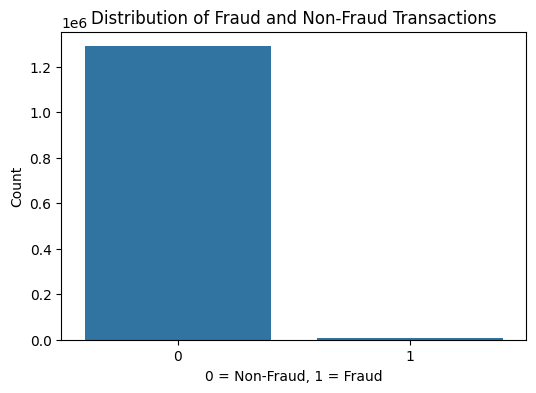

In [24]:
#Now the dataset is ready so lets plot some visuals for clear Understanding


#1. Distribution of target variable

plt.figure(figsize=(6,4))
sns.countplot(x='is_fraud', data=train_df)
plt.title('Distribution of Fraud and Non-Fraud Transactions')
plt.xlabel('0 = Non-Fraud, 1 = Fraud')
plt.ylabel('Count')
plt.show()

The plot clearly says about the distribution of fraud(1) and non-fraud(0). the data is imbalanced as the count of non fraud is much much greater then count of fraud which will furher lead to false value predictions

In [ ]:
# to eliminate this will we use Class Weight Adjustment (allows you to automatically adjust class weights...it gives more importance to fraud which is an minority class.)


#feature-selection
X_train = train_df.drop(columns=['is_fraud'])
y_train = train_df['is_fraud']

X_test = test_df.drop(columns=['is_fraud'])
y_test = test_df['is_fraud']

#train & test split
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)


#Class weight adjustments
model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)
y_pred=model.predict(X_val)


In [30]:
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
accuracy = accuracy_score(y_val, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Accuracy: {accuracy:.4f}")

Precision: 0.9478
Recall: 0.7053
F1 Score: 0.8088
Accuracy: 0.9980


              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257815
           1       0.95      0.71      0.81      1520

    accuracy                           1.00    259335
   macro avg       0.97      0.85      0.90    259335
weighted avg       1.00      1.00      1.00    259335



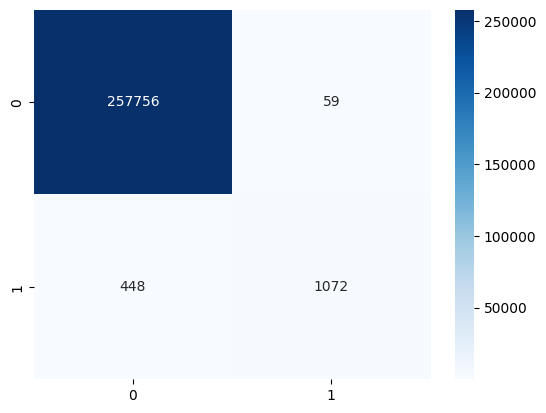

In [34]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_val, y_pred))
sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt='d', cmap='Blues')
plt.show()

In [ ]:
sample = {
    'merchant': ['Walmart'],
    'category': ['shopping'],
    'amt': [200.5],
    'gender': ['M'],
    'lat': [37.77],
    'long': [-122.4],
    'city_pop': [870000],
    'job': ['Engineer'],
    'merch_lat': [37.78],
    'merch_long': [-122.41],
    'hrs': [14],
    'days_of_week': ['Monday']
}

sample_df = pd.DataFrame(sample)

sample_df['gender'] = sample_df['gender'].map({'M': 0, 'F': 1})


categorical_col=['merchant','category','job','days_of_week']
for col1 in categorical_col:
    sample_df[col1]=le.fit_transform(sample_df[col1])



prediction = model.predict(sample_df)

if prediction[0] == 1:
    print("Fraud Transaction!")
else:
    print("Non-Fraud Transaction!")

Non-Fraud Transaction!


In [84]:
fraud_df=test_df[test_df['is_fraud']==1]

print(fraud_df)

        merchant  category      amt  gender      lat      long  city_pop  job  \
1685         226         5    24.84       1  31.8599 -102.7413        23  109   
1767         523         8   780.52       0  42.5545  -90.3508      1306  367   
1781         451         0   620.33       0  42.5545  -90.3508      1306  367   
1784         238        11  1077.69       0  30.4590  -90.9027     71335  214   
1857         246        12   842.65       1  31.8599 -102.7413        23  109   
...          ...       ...      ...     ...      ...       ...       ...  ...   
517197       670        12  1041.51       0  34.6323  -89.8855     14462  112   
517274       349        12   868.09       0  34.6323  -89.8855     14462  112   
517341       443        11  1039.42       0  34.6323  -89.8855     14462  112   
517529        29         4   289.27       0  34.6323  -89.8855     14462  112   
517571       281         8   766.38       0  34.6323  -89.8855     14462  112   

        merch_lat  merch_lo